

This section imports the necessary libraries for data manipulation, visualization, machine learning, . It also initializes the SHAP JavaScript visualization library.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import shap
shap.initjs()

### Data Loading

Load the dataset from the CSV file into a pandas DataFrame.

In [ ]:
df = pd.read_csv("new_fraud_dataset.csv")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

### Shuffle the DataFrame

Randomly shuffle the rows of the DataFrame to mix the fraud and non-fraud cases.

In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
print("HEAD")
print(df.head())
print("TAIL")
print(df.tail())

HEAD
   step      type      amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0   305  TRANSFER  1754597.44   C276718485     1754597.44            0.00   
1     9   CASH_IN    77711.78  C1624542973    11952838.64     12030550.43   
2   323  CASH_OUT   351445.60  C1091509719        9740.00            0.00   
3   408  TRANSFER   170464.63  C1333717875       15349.00            0.00   
4   323  CASH_OUT   224623.29  C1615855895           0.00            0.00   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  C1947776397            0.00            0.00        1               0  
1  C1544755390      2558033.18      7717841.34        0               0  
2   C231199834            0.00       351445.60        0               0  
3  C1040254896       543721.02       714185.66        0               0  
4   C762981829       966607.92      1191231.21        0               0  
TAIL
       step      type      amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
29

### Box Plots for Numerical Features

Visualize the distribution of numerical features using box plots to identify potential outliers and understand the data spread.

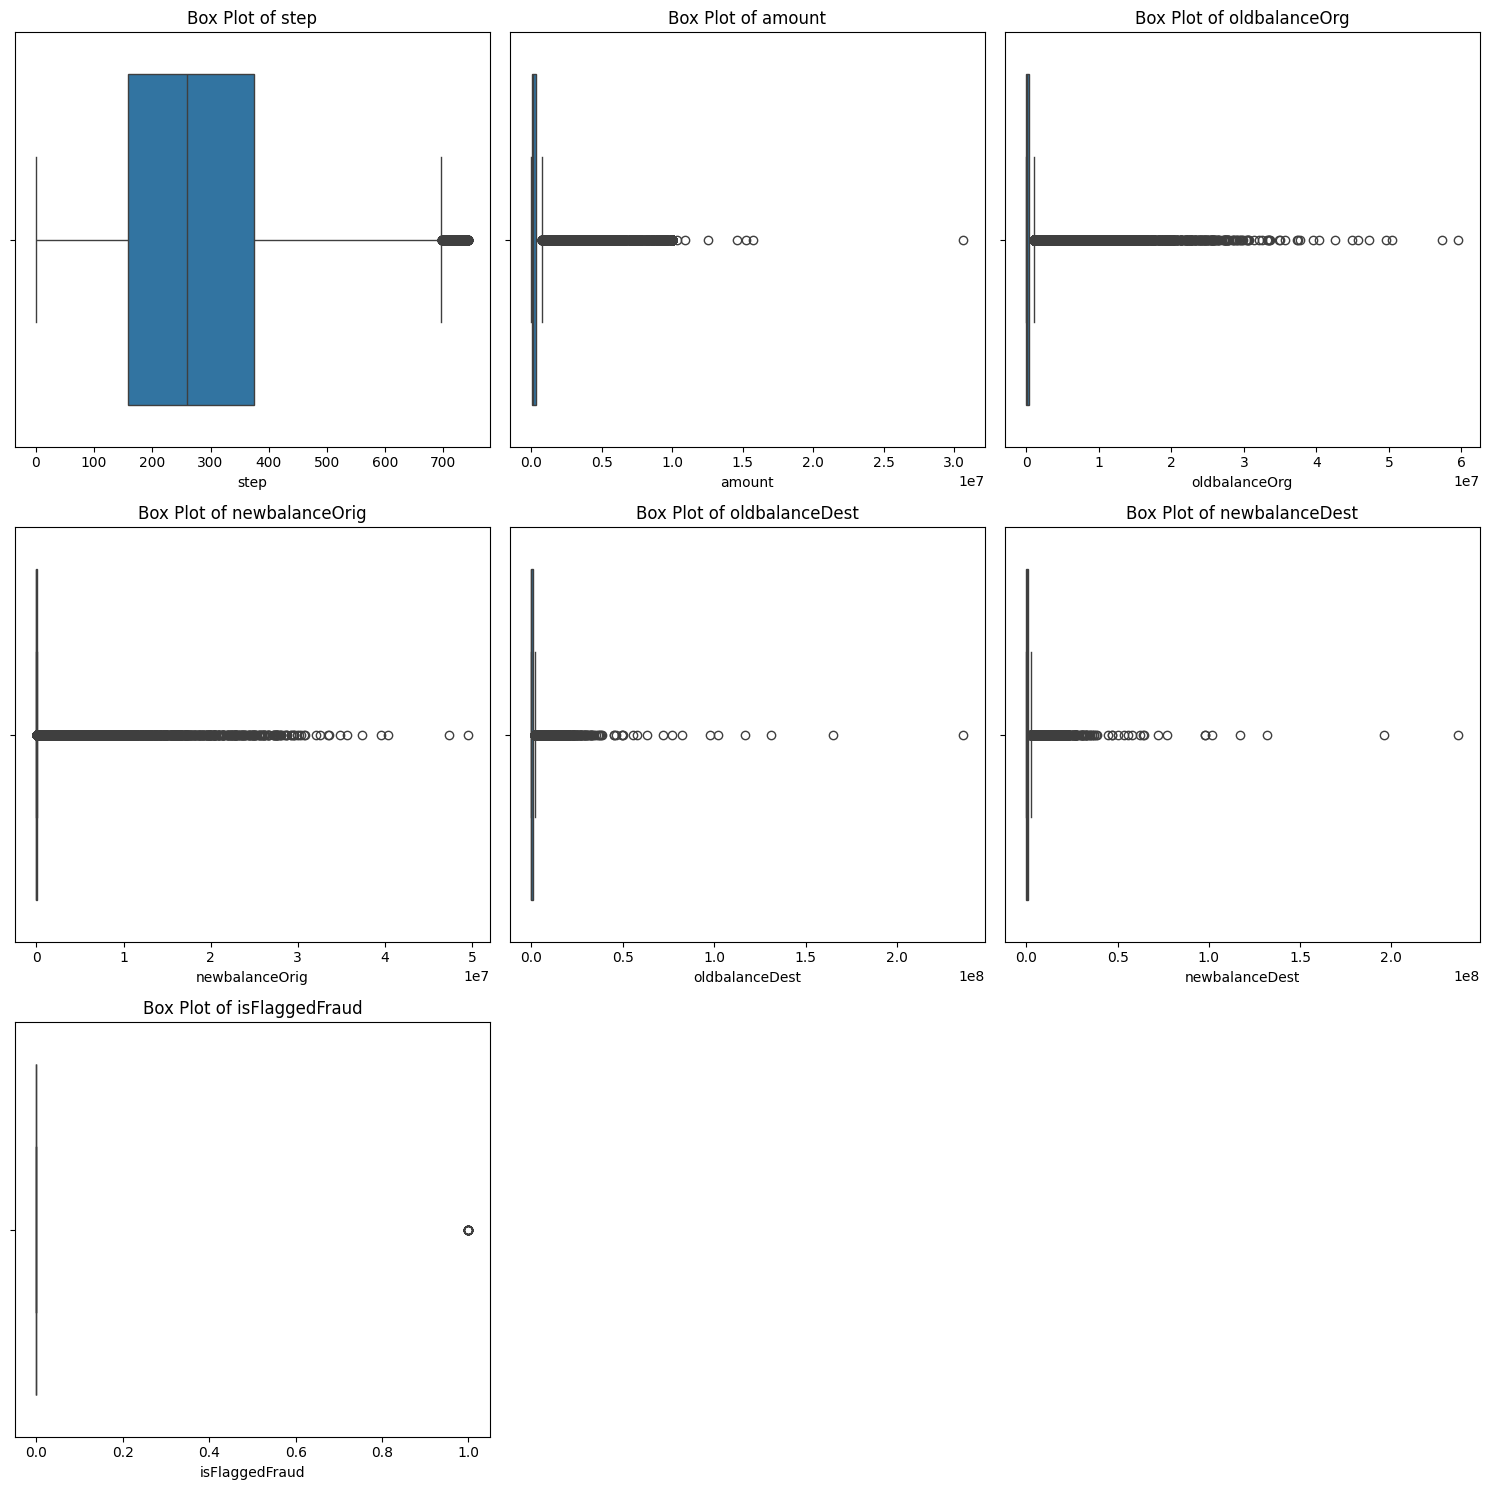

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'isFraud' in numerical_cols:
    numerical_cols.remove('isFraud')

# Determine the number of rows and columns for the subplot grid
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

checked if any null values

In [ ]:
print(df.info())
print("")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            30000 non-null  int64  
 1   type            30000 non-null  object 
 2   amount          30000 non-null  float64
 3   nameOrig        30000 non-null  object 
 4   oldbalanceOrg   30000 non-null  float64
 5   newbalanceOrig  30000 non-null  float64
 6   nameDest        30000 non-null  object 
 7   oldbalanceDest  30000 non-null  float64
 8   newbalanceDest  30000 non-null  float64
 9   isFraud         30000 non-null  int64  
 10  isFlaggedFraud  30000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 2.5+ MB
None

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


## Data Cleaning and EDA Techniques



### Box Plots for All Numerical Features

Visualize the distribution of all numerical features using box plots.

### Calculate IQR for Amount and Handle Outliers

This calculates the Interquartile Range (IQR) for the 'amount' column and then caps the outliers using the calculated IQR bounds.

In [ ]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")

# You can also define bounds for outliers using the IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")

Q1 (25th percentile): 20111.2175
Q3 (75th percentile): 320977.49
IQR: 300866.27249999996
Lower bound for outliers: -431188.1912499999
Upper bound for outliers: 772276.8987499999


### Handling Outliers using IQR

Cap the outliers in the 'amount' column using the calculated IQR bounds.

Q1 (25th percentile): 20111.2175
Q3 (75th percentile): 320977.49
IQR: 300866.27249999996
Lower bound for outliers: -431188.1912499999
Upper bound for outliers: 772276.8987499999
Original 'amount' statistics:
count    3.000000e+04
mean     5.268642e+05
std      1.447044e+06
min      0.000000e+00
25%      2.011122e+04
50%      1.207170e+05
75%      3.209775e+05
max      3.066337e+07
Name: amount, dtype: float64

Capped 'amount' statistics:
count     30000.000000
mean     223652.831201
std      256704.801273
min           0.000000
25%       20111.217500
50%      120716.975000
75%      320977.490000
max      772276.898750
Name: amount_capped, dtype: float64


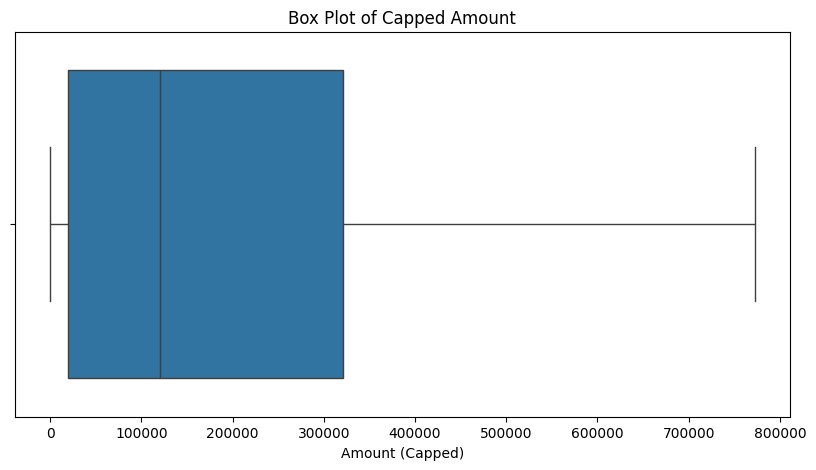

In [ ]:
# Calculate IQR
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers using the IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")

# Cap outliers in the 'amount' column
df['amount_capped'] = df['amount'].clip(lower=lower_bound, upper=upper_bound)

# You can compare the original and capped 'amount' columns
print("Original 'amount' statistics:")
print(df['amount'].describe())
print("\nCapped 'amount' statistics:")
print(df['amount_capped'].describe())

# You can also visualize the distribution after capping
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['amount_capped'])
plt.title('Box Plot of Capped Amount')
plt.xlabel('Amount (Capped)')
plt.show()

Capped 'oldbalanceOrg' column statistics:
count    3.000000e+04
mean     2.683346e+05
std      3.857824e+05
min      0.000000e+00
25%      1.110000e+02
50%      4.309200e+04
75%      4.050349e+05
max      1.012421e+06
Name: oldbalanceOrg_capped, dtype: float64
------------------------------
Capped 'newbalanceOrig' column statistics:
count     30000.000000
mean      26055.184977
std       43398.601233
min           0.000000
25%           0.000000
50%           0.000000
75%       42202.057500
max      105505.143750
Name: newbalanceOrig_capped, dtype: float64
------------------------------
Capped 'oldbalanceDest' column statistics:
count    3.000000e+04
mean     4.309824e+05
std      6.282437e+05
min      0.000000e+00
25%      0.000000e+00
50%      1.445361e+04
75%      6.857222e+05
max      1.714305e+06
Name: oldbalanceDest_capped, dtype: float64
------------------------------
Capped 'newbalanceDest' column statistics:
count    3.000000e+04
mean     6.882585e+05
std      9.541270e+05
min

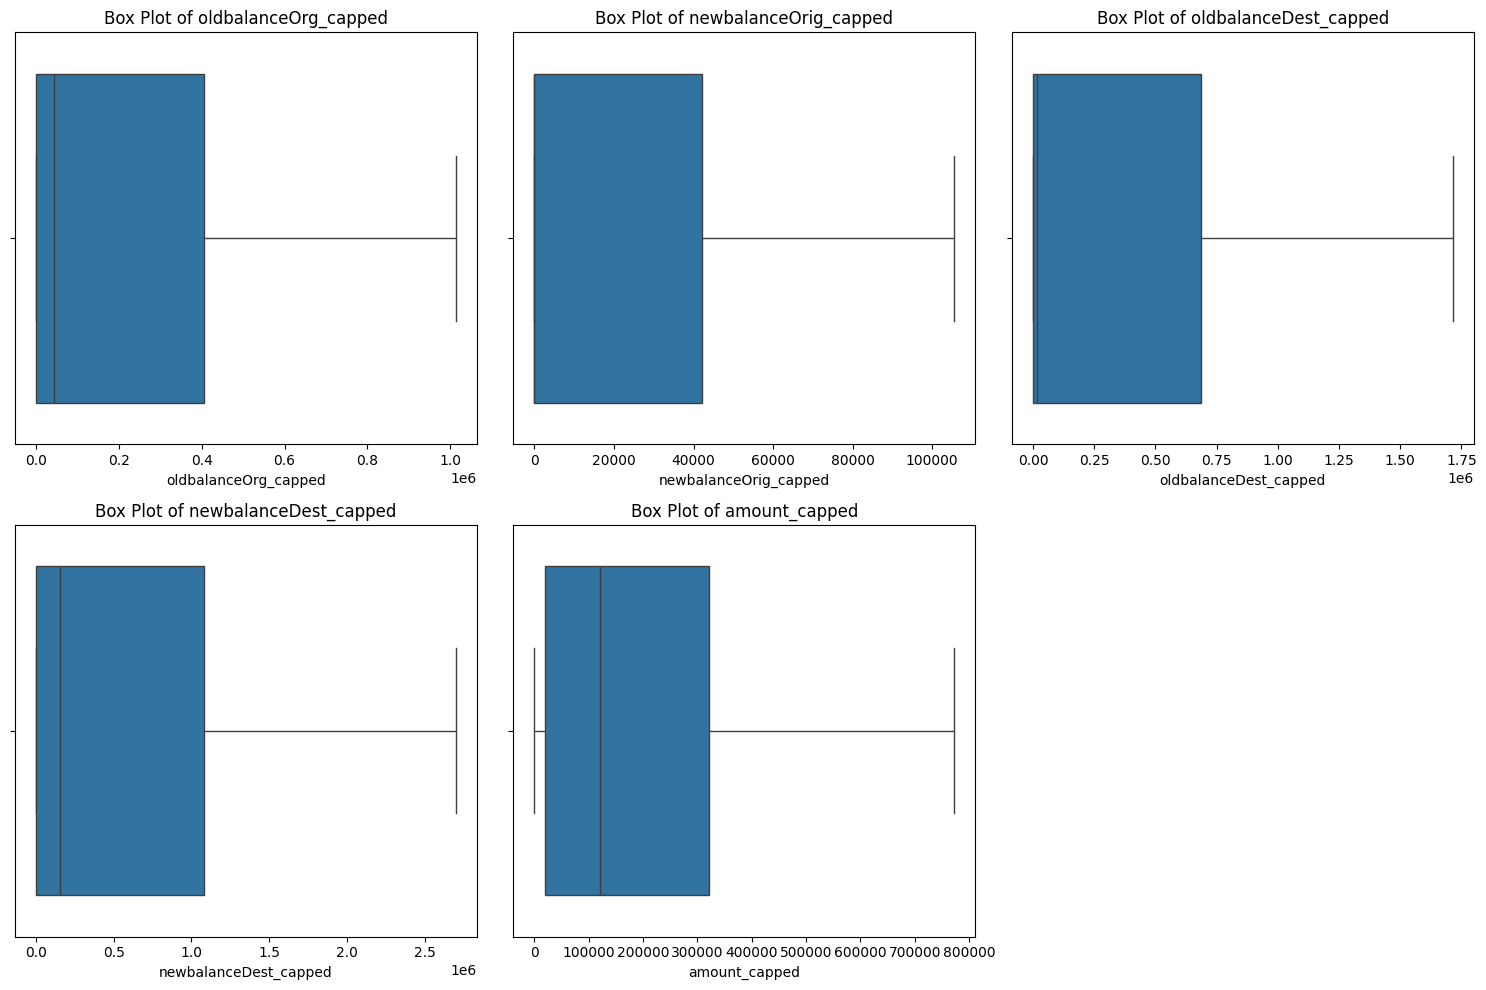

In [ ]:

cols_to_cap = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[f'{col}_capped'] = df[col].clip(lower=lower_bound, upper=upper_bound)

    print(f"Capped '{col}' column statistics:")
    print(df[f'{col}_capped'].describe())
    print("-" * 30)

# You can also visualize the distribution after capping
plt.figure(figsize=(15, 10))
capped_cols = [f'{col}_capped' for col in cols_to_cap] + ['amount_capped']
for i, col in enumerate(capped_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

### Distribution of Numerical Features (Sampled Data)

Histograms visualizing the distribution of numerical features in the sampled dataset.

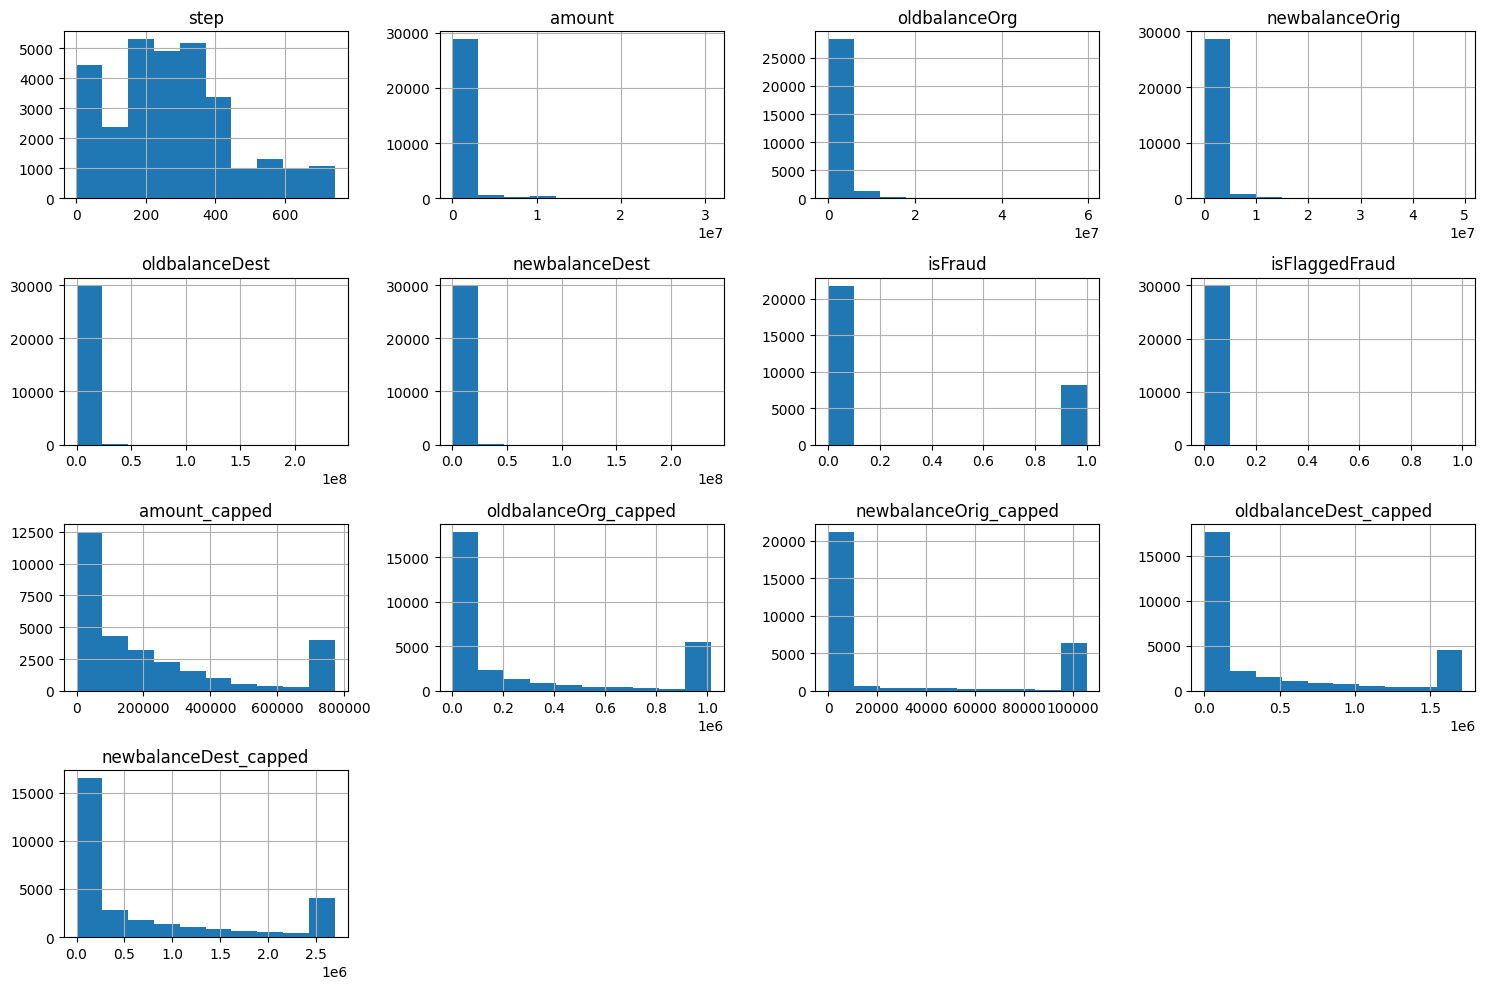

In [ ]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

In [ ]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")



Number of duplicate rows: 0


### Check for Missing Values

This code provides a summary of missing values per column.

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
step                     0
type                     0
amount                   0
nameOrig                 0
oldbalanceOrg            0
newbalanceOrig           0
nameDest                 0
oldbalanceDest           0
newbalanceDest           0
isFraud                  0
isFlaggedFraud           0
amount_capped            0
oldbalanceOrg_capped     0
newbalanceOrig_capped    0
oldbalanceDest_capped    0
newbalanceDest_capped    0
dtype: int64


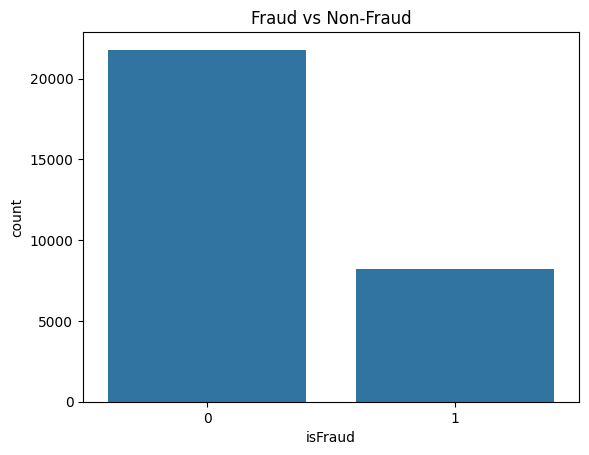

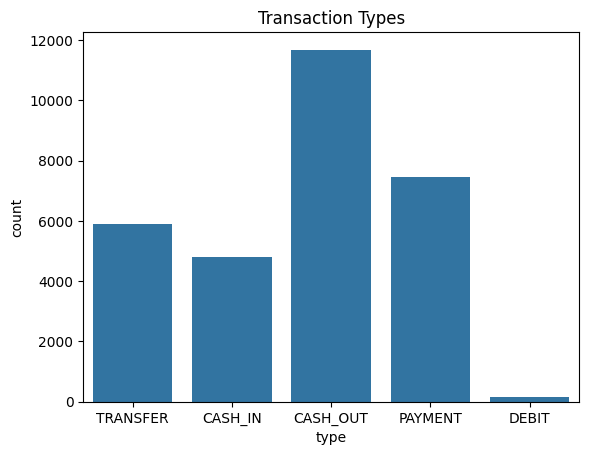

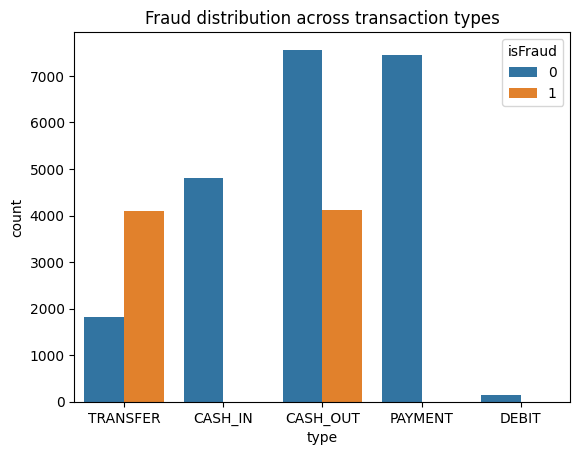

In [ ]:
# Target distribution
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

# Transaction type distribution
sns.countplot(x="type", data=df)
plt.title("Transaction Types")
plt.show()

# Fraud vs Non-fraud by type
sns.countplot(x="type", hue="isFraud", data=df)
plt.title("Fraud distribution across transaction types")
plt.show()



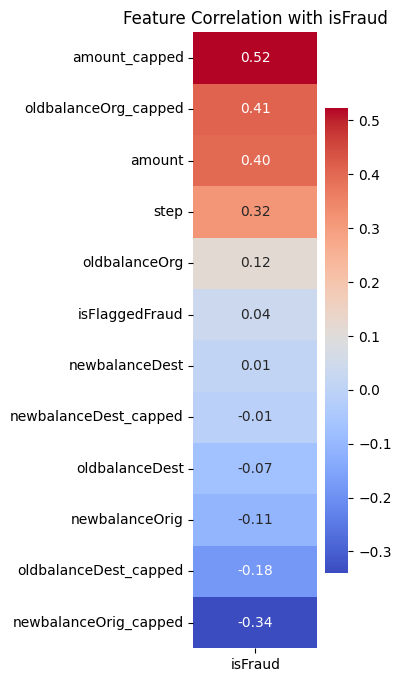

In [ ]:
plt.figure(figsize=(2,8))
sns.heatmap(df.select_dtypes(include=np.number).corr()[['isFraud']].drop('isFraud').sort_values(by='isFraud', ascending=False), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation with isFraud")
plt.show()

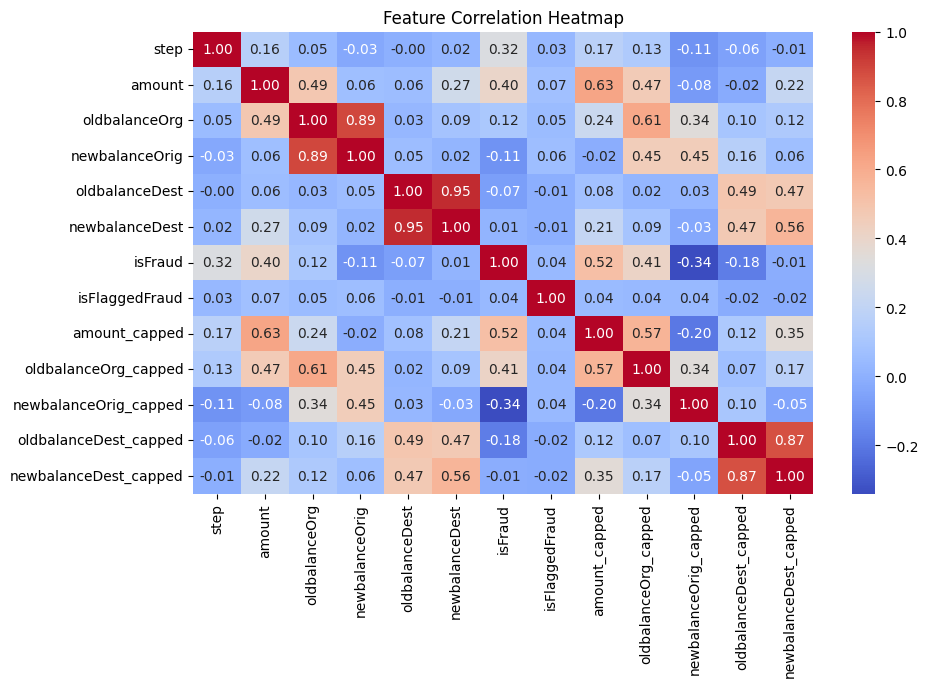

In [ ]:
plt.figure(figsize=(10,6))
numerical_df = df.select_dtypes(include=np.number) # Select only numerical columns
sns.heatmap(numerical_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

drop the useless column

In [ ]:
# Drop IDs and useless columns
df = df.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"])

# Drop rows where target is missing
df = df.dropna(subset=["isFraud"])

# Features & target
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

# One-hot encode categorical
X = pd.get_dummies(X, columns=["type"], drop_first=True)

Train-Test Split and Overlap Check

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Find overlapping indices in X_test
overlapping_indices = X_test.index[X_test.apply(tuple, axis=1).isin(X_train.apply(tuple, axis=1))]

# Drop overlapping rows from X_test and y_test
X_test = X_test.drop(overlapping_indices)
y_test = y_test.drop(overlapping_indices)

print(f"Removed {len(overlapping_indices)} overlapping rows from the test set.")
print(f"New size of X_test: {len(X_test)}")
print(f"New size of y_test: {len(y_test)}")

Removed 6 overlapping rows from the test set.
New size of X_test: 8994
New size of y_test: 8994


### Model Training

Train a RandomForestClassifier model on the training data to learn the patterns associated with fraudulent transactions.

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

### Model Interpretability with SHAP

Prepare the data and initialize the SHAP explainer to understand the feature importance and how individual features influence the model's predictions.

In [ ]:
# Convert boolean columns to float for SHAP compatibility
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Sample X_test for faster SHAP calculation
X_test_sampled = X_test.sample(n=1000, random_state=42)

explainer = shap.Explainer(model, X_train)
shap_values_test = explainer(X_test_sampled)

 98%|===================| 1965/2000 [00:50<00:00]       

### Check for Data Overlap between Training and Testing Sets

Verify if any rows in the test dataset are also present in the training dataset.

In [ ]:
# Convert DataFrames to sets of tuples for efficient comparison
X_train_set = set(map(tuple, X_train.values))
X_test_set = set(map(tuple, X_test.values))

# Find the intersection of the two sets
overlap = X_train_set.intersection(X_test_set)

if overlap:
    print(f"Found {len(overlap)} overlapping rows between X_train and X_test.")

else:
    print("No overlapping rows found between X_train and X_test.")

No overlapping rows found between X_train and X_test.


### Predict Single Transaction

Define and use a function to predict the outcome (Fraud or Not Fraud) and probability for a single transaction based on the trained model.

In [ ]:
def predict_transaction(model, input_data, X_columns):
    df_input = pd.DataFrame([input_data])
    df_input = pd.get_dummies(df_input)
    df_input = df_input.reindex(columns=X_columns, fill_value=0)

    prediction = model.predict(df_input)[0]
    prob = model.predict_proba(df_input)[0][1]

    return "Fraud" if prediction == 1 else "Not Fraud", prob

### Example Usage of Predict Single Transaction Function

This code defines a sample transaction and then uses the `predict_transaction` function to get the model's prediction and the fraud probability for this specific transaction.

In [ ]:
fraud_tx = {
    "step": 350,
    "type": "TRANSFER",
    "amount": 200000.0,
    "oldbalanceOrg": 200000.0,
    "newbalanceOrig": 0.0,
    "oldbalanceDest": 0.0,
    "newbalanceDest": 200000.0
}

result, prob = predict_transaction(model, fraud_tx, X_train.columns)
print("Prediction:", result)
print("Fraud probability:", prob)

Prediction: Not Fraud
Fraud probability: 0.47


### Predict Single Transaction with SHAP Explanation

Define a function to predict the outcome and probability for a single transaction and generate SHAP values to explain the prediction.

In [ ]:
def predict_transaction_with_shap(model, explainer, input_dict, reference_columns):
    df_new = pd.DataFrame([input_dict])
    if "type" in df_new.columns:
        df_new = pd.get_dummies(df_new, columns=["type"], drop_first=True)
    df_new = df_new.reindex(columns=reference_columns, fill_value=0)

    pred_class = model.predict(df_new)[0]
    pred_prob = model.predict_proba(df_new)[0, 1]

    shap_values_new = explainer(df_new)

    return ("Fraud" if pred_class == 1 else "Not Fraud"), float(pred_prob), shap_values_new

### SHAP Beeswarm Plot

Visualize the distribution of SHAP values for each feature to understand their overall impact on the model's output across the dataset. This plot shows which features are most important and how they affect the prediction for different instances.

100%|===================| 1996/2000 [00:51<00:00]       

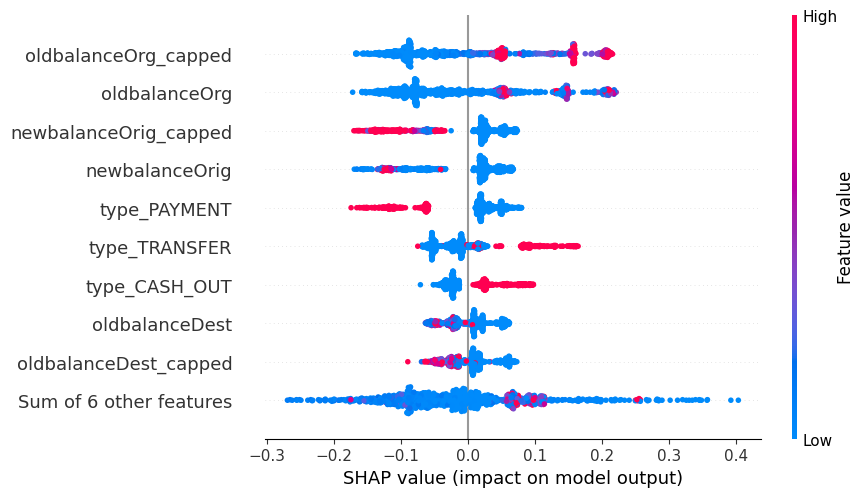

In [ ]:
shap_values_test = explainer(X_test_sampled)   # or full X_test if you can handle the computation
shap.plots.beeswarm(shap_values_test[:, :, 1])

Most important features (ranked top to bottom)

oldbalanceOrg and newbalanceOrig are the strongest drivers of fraud prediction.

Transaction type features (type_PAYMENT, type_CASH_OUT, type_TRANSFER) also matter a lot.

Features lower on the chart (like type_DEBIT, step) had less impact overall.

In [ ]:
# Look at the first 5 rows of test data with labels
X_test.head(), y_test.head()

(        step     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
 8662   284.0  183497.08           0.00            0.00      9131004.30   
 8089   743.0  339682.13      339682.13            0.00            0.00   
 27736   34.0   11944.68      100677.00        88732.32            0.00   
 15970  300.0   32846.78           0.00            0.00            0.00   
 11457  302.0  136849.54           0.00            0.00      3229842.63   
 
        newbalanceDest  amount_capped  oldbalanceOrg_capped  \
 8662       9314501.38      183497.08                  0.00   
 8089             0.00      339682.13             339682.13   
 27736            0.00       11944.68             100677.00   
 15970            0.00       32846.78                  0.00   
 11457      3366692.17      136849.54                  0.00   
 
        newbalanceOrig_capped  oldbalanceDest_capped  newbalanceDest_capped  \
 8662                    0.00           1.714305e+06           2.699183e+06   
 8089     

### Select and Examine a Single Test Instance

Choose a specific row from the test set to examine its true label and prepare it for individual prediction and SHAP explanation.

In [ ]:

sample_idx = 3
sample_X = X_test.iloc[[sample_idx]]
sample_y = y_test.iloc[sample_idx]

print("True label:", "Fraud" if sample_y == 1 else "Not Fraud")

True label: Not Fraud


In [ ]:
# Make prediction
pred = model.predict(sample_X)[0]
prob = model.predict_proba(sample_X)[0][1]

print("Predicted:", "Fraud" if pred == 1 else "Not Fraud")
print("Fraud probability:", prob)

Predicted: Not Fraud
Fraud probability: 0.0


### SHAP Waterfall Plot for Single Instance

Visualize the SHAP values for the selected transaction using a waterfall plot. This plot shows how each feature contributes to pushing the prediction from the base value to the final predicted value, explaining why the model made that specific prediction.

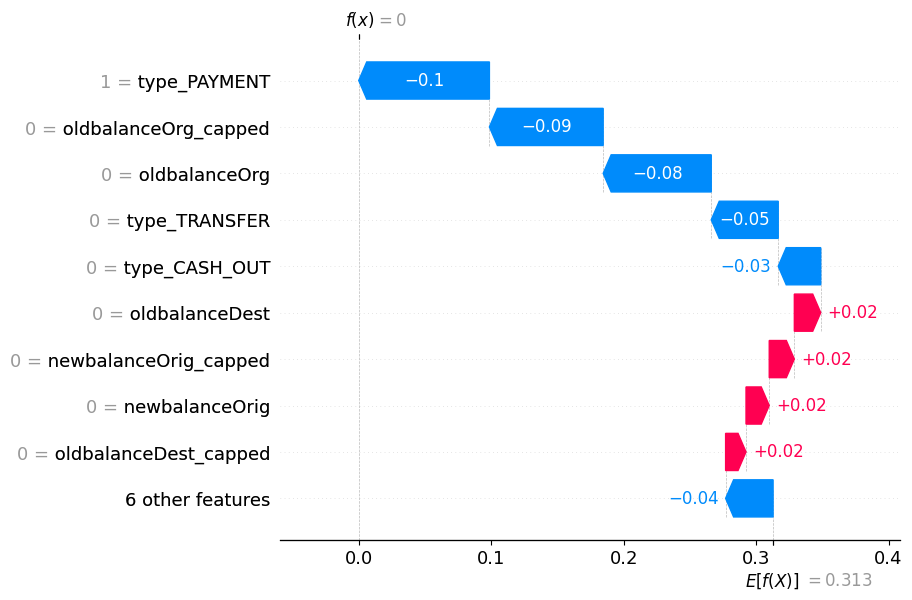

In [ ]:

shap_values_sample = explainer(sample_X)
# Show waterfall for Fraud class
shap.plots.waterfall(shap_values_sample[0, :, 1])

In [ ]:
sample_idx = 8089
sample_X = X_test.iloc[[sample_idx]]
sample_y = y_test.iloc[sample_idx]

print("True label:", "Fraud" if sample_y == 1 else "Not Fraud")

True label: Fraud


In [ ]:
pred = model.predict(sample_X)[0]
prob = model.predict_proba(sample_X)[0][1]

print("Predicted:", "Fraud" if pred == 1 else "Not Fraud")
print("Fraud probability:", prob)

Predicted: Fraud
Fraud probability: 1.0


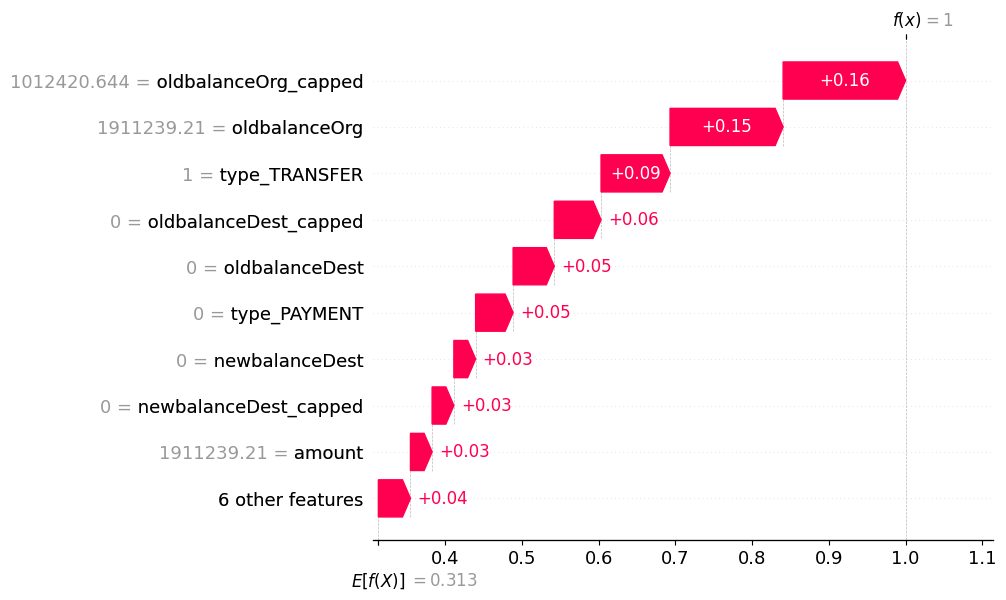

In [ ]:
shap_values_sample = explainer(sample_X)
# water fall plot on other sample
shap.plots.waterfall(shap_values_sample[0, :, 1])

### Model Evaluation

Evaluate the performance of the trained model on the test set using standard classification metrics (Precision, Recall, F1-Score, ROC AUC) and visualize the results with a Confusion Matrix.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      6536
           1       0.98      0.99      0.99      2458

    accuracy                           0.99      8994
   macro avg       0.99      0.99      0.99      8994
weighted avg       0.99      0.99      0.99      8994

Confusion Matrix:
[[6495   41]
 [  18 2440]]
ROC AUC: 0.9984749607357088


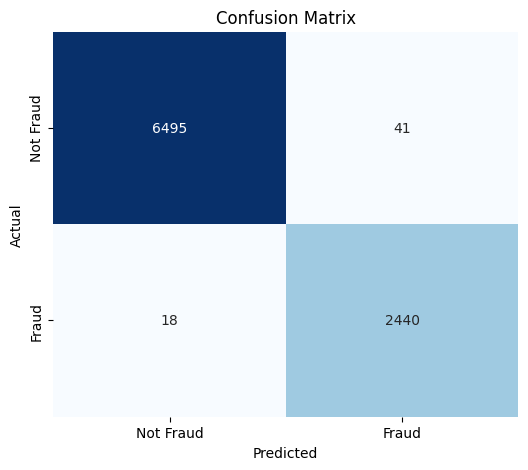

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC Curve
Visualize the Receiver Operating Characteristic (ROC) curve to evaluate the model's ability to distinguish between the two classes (fraud and non-fraud). The ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various

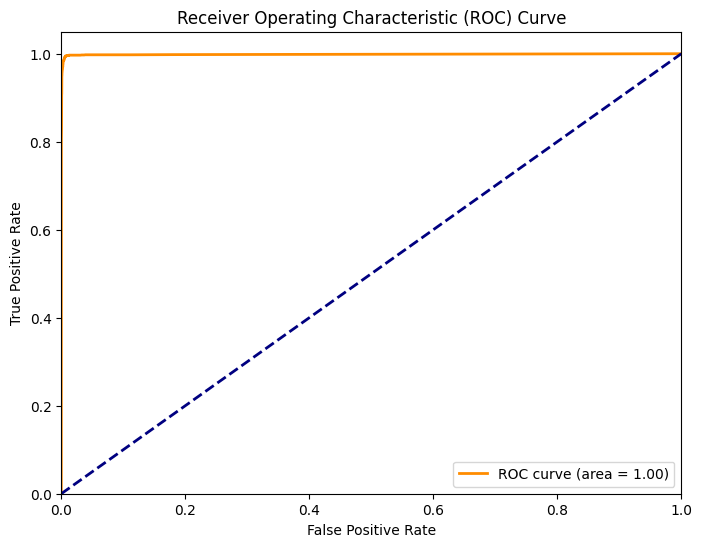

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' ROC Curve')
plt.legend(loc="lower right")
plt.show()

## Import necessary libraries

### Subtask:
Import necessary libraries for creating interactive widgets and displaying output.


**Reasoning**:
Import the necessary libraries for creating interactive widgets and displaying output.



In [ ]:
import ipywidgets as widgets
from IPython.display import display

## Create input widgets

### Subtask:
Create interactive widgets for each feature required for the transaction prediction.


**Reasoning**:
Create ipywidgets for each feature based on the instructions.



In [ ]:
step_widget = widgets.BoundedIntText(
    description='Step:',
    min=0,
    max=744,
    value=1
)

type_widget = widgets.Dropdown(
    description='Type:',
    options=['CASH_OUT', 'TRANSFER', 'CASH_IN', 'PAYMENT', 'DEBIT']
)

amount_widget = widgets.FloatText(
    description='Amount:',
    min=0.0,
    value=0.0
)

oldbalanceOrg_widget = widgets.FloatText(
    description='Old Balance Originator:',
    min=0.0,
    value=0.0
)

newbalanceOrig_widget = widgets.FloatText(
    description='New Balance Originator:',
    min=0.0,
    value=0.0
)

oldbalanceDest_widget = widgets.FloatText(
    description='Old Balance Destination:',
    min=0.0,
    value=0.0
)

newbalanceDest_widget = widgets.FloatText(
    description='New Balance Destination:',
    min=0.0,
    value=0.0
)

## Create a button widget

### Subtask:
Add a button that triggers the prediction when clicked.


**Reasoning**:
Create a button widget for triggering the prediction.



In [ ]:
predict_button = widgets.Button(description="Predict")

## Create an output widget

### Subtask:
Set up an output area to display the prediction results.


**Reasoning**:
Instantiate an Output widget to display the prediction results.



In [ ]:
from ipywidgets import Output
output_widget = Output()

## Define a function to handle button clicks

### Subtask:
Write a function that retrieves the values from the input widgets, uses the `predict_transaction` function, and displays the results in the output widget.


**Reasoning**:
Define the prediction function that retrieves widget values, calls the prediction function, and displays the results in the output widget, and then link the button to this function.



In [ ]:
def on_predict_button_clicked(button):
    with output_widget:
        output_widget.clear_output()
        input_data = {
            "step": step_widget.value,
            "type": type_widget.value,
            "amount": amount_widget.value,
            "oldbalanceOrg": oldbalanceOrg_widget.value,
            "newbalanceOrig": newbalanceOrig_widget.value,
            "oldbalanceDest": oldbalanceDest_widget.value,
            "newbalanceDest": newbalanceDest_widget.value
        }

        # Use the predict_transaction_with_shap function
        result, prob, shap_values_new = predict_transaction_with_shap(
            model, explainer, input_data, X_train.columns
        )

        print("Prediction:", result)
        print("Fraud probability:", prob)

        # Display the SHAP waterfall plot
        print("\nSHAP Explanation:")
        shap.plots.waterfall(shap_values_new[0, :, 1])


predict_button.on_click(on_predict_button_clicked)

## Link widgets and display the interface

### Subtask:
Arrange the widgets and the output area, and display them using `IPython.display.display`.


**Reasoning**:
Arrange the widgets in a container and display them along with the output widget.



In [ ]:
def predict_transaction(model, input_data, X_columns):
    df_input = pd.DataFrame([input_data])
    df_input = pd.get_dummies(df_input)
    df_input = df_input.reindex(columns=X_columns, fill_value=0)

    prediction = model.predict(df_input)[0]
    prob = model.predict_proba(df_input)[0][1]

    return "Fraud" if prediction == 1 else "Not Fraud", prob

In [ ]:
input_widgets = widgets.VBox([
    step_widget,
    type_widget,
    amount_widget,
    oldbalanceOrg_widget,
    newbalanceOrig_widget,
    oldbalanceDest_widget,
    newbalanceDest_widget,
    predict_button
])

display(input_widgets, output_widget)

Output()